<a href="https://colab.research.google.com/github/VanshikaDhiman14/Computer-Vision-Labsheets/blob/main/Labsheet4cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Vanshika Dhiman(CU24250228)

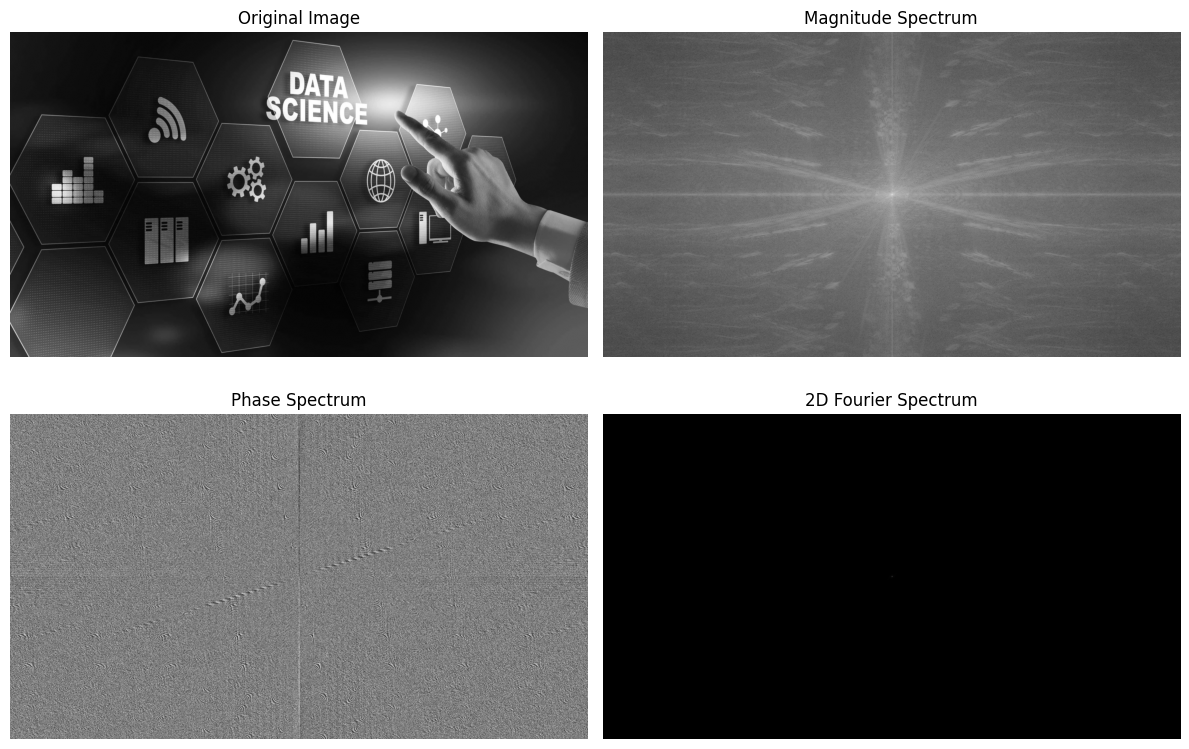

Vanshika Dhiman
CU24250228


In [ ]:
# 1. Build a tool that computes and visualizes the 2D Fourier spectrum(magnitude and phase) of an image.
import cv2
import numpy as np
import matplotlib.pyplot as plt
#Read image in grayscale
image=cv2.imread("img2.jpg",cv2.IMREAD_GRAYSCALE)
if image is None:
  print("Error: Image not found.")
  exit()
# Compute 2D Fourier Transform
f=np.fft.fft2(image)
f_shift=np.fft.fftshift(f)
#Calculate magnitude spectrum
magnitude=np.abs(f_shift)

#Using logarithmic scale
magnitude_spectrum=np.log1p(magnitude)
#Calculate phase spectrum
phase_spectrum=np.angle(f_shift)

# Display Results
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.imshow(image,cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(magnitude_spectrum,cmap="gray")
plt.title("Magnitude Spectrum")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(phase_spectrum,cmap="gray")
plt.title("Phase Spectrum")
plt.axis("off")
plt.subplot(2,2,4)
plt.imshow(np.abs(f_shift),cmap="gray")
plt.title("2D Fourier Spectrum")
plt.axis("off")
plt.tight_layout()
plt.show()
print("Vanshika Dhiman")
print("CU24250228")

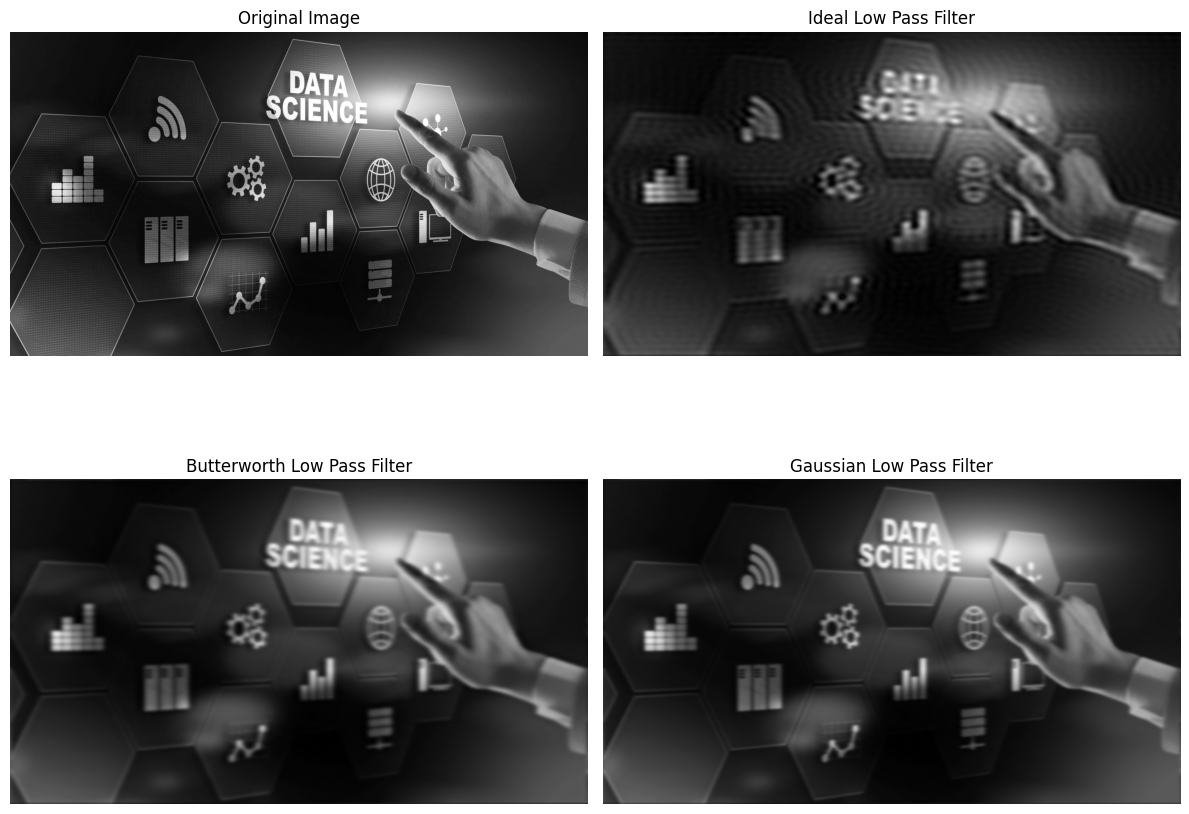

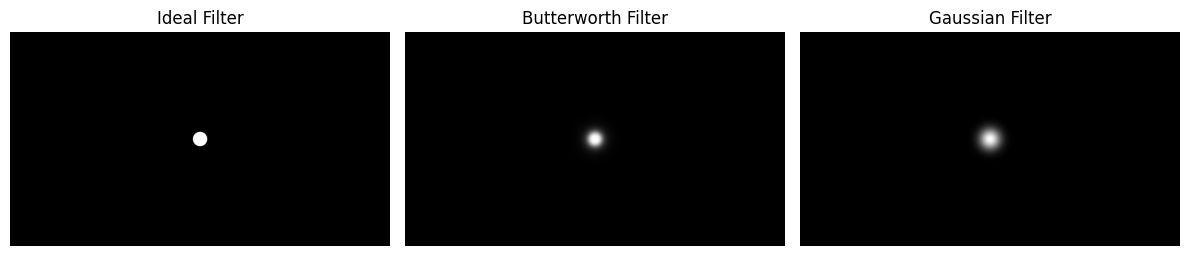

Vanshika Dhiman
CU24250228


In [ ]:
#  2. Develop a frequency domain low pass filter (ideal,butterworth, and Gaussian)and comapre the resulting blur effects.
import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread("img2.jpg",cv2.IMREAD_GRAYSCALE)
if image is None:
  print("Error:Image not found")
  exit()
# get image dimensions
rows, cols = image.shape

crow=rows//2
ccol=cols//2

# 1.Fourier Transform
# applying 2D Fourier Transform
f=np.fft.fft2(image)
#Shift zero frequency to center
f_shift=np.fft.fftshift(f)

# 2.Creating Distance Matrix
u=np.arange(cols)
v=np.arange(rows)
U,V=np.meshgrid(u,v)
#Distance from center
D=np.sqrt((U-ccol)**2+(V-crow)**2)
#Cutoff frequency
D0=50

# 3.Ideal low pass Filter
ideal_filter=np.zeros((rows,cols))
ideal_filter[D<=D0]=1

# 4.Butterworth Low pass filter
order = 2

butterworth_filter = 1 / (
    1 + (D / D0) ** (2 * order)
)
# 5.Gaussian Low Pass Filter
gaussian_filter = np.exp(
    -(D ** 2) / (2 * (D0 ** 2))
)
#6. Apply filters
# Ideal
ideal_result = f_shift * ideal_filter

# Butterworth
butterworth_result = f_shift * butterworth_filter

# Gaussian
gaussian_result = f_shift * gaussian_filter

# 7.Inverse Fourier Transform
def inverse_fourier(filtered):
    """
    Convert filtered frequency-domain image
    back to spatial domain.
    """

    # Shift back
    shifted = np.fft.ifftshift(filtered)

    # Inverse Fourier Transform
    result = np.fft.ifft2(shifted)

    # Take magnitude
    result = np.abs(result)

    # Normalize to 0-255
    result = cv2.normalize(
        result,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    return result.astype(np.uint8)


# Get filtered images
ideal_image = inverse_fourier(ideal_result)
butterworth_image = inverse_fourier(butterworth_result)
gaussian_image = inverse_fourier(gaussian_result)



# 8. DISPLAY RESULTS

plt.figure(figsize=(12, 10))

# Original image
plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Ideal LPF
plt.subplot(2, 2, 2)
plt.imshow(ideal_image, cmap="gray")
plt.title("Ideal Low Pass Filter")
plt.axis("off")

# Butterworth LPF
plt.subplot(2, 2, 3)
plt.imshow(butterworth_image, cmap="gray")
plt.title("Butterworth Low Pass Filter")
plt.axis("off")

# Gaussian LPF
plt.subplot(2, 2, 4)
plt.imshow(gaussian_image, cmap="gray")
plt.title("Gaussian Low Pass Filter")
plt.axis("off")

plt.tight_layout()
plt.show()


# 9. DISPLAY FILTERS
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(ideal_filter, cmap="gray")
plt.title("Ideal Filter")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(butterworth_filter, cmap="gray")
plt.title("Butterworth Filter")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gaussian_filter, cmap="gray")
plt.title("Gaussian Filter")
plt.axis("off")

plt.tight_layout()
plt.show()
print("Vanshika Dhiman")
print("CU24250228")

Image loaded successfully!!
Image size:  (1485, 2640)


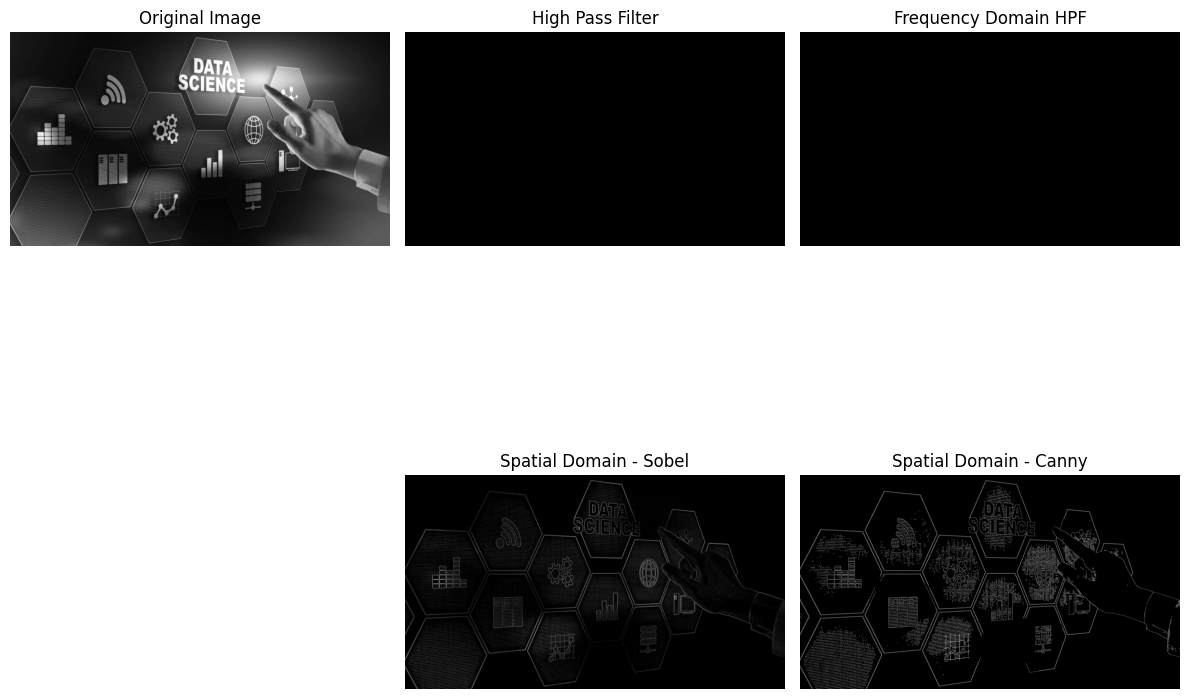

Vanshika Dhiman
CU24250228


In [ ]:
# 3. Create a frequency dimain high pass filter yo enhance edges,and compare the result with spatial domain edge detection.
import cv2
import numpy as np
import matplotlib.pyplot as plt

image=cv2.imread("img2.jpg",cv2.IMREAD_GRAYSCALE)
if image is None:
  print("Error: Could not read the selected image.")
  exit()
print("Image loaded successfully!!")
print("Image size: ",image.shape)

# Fourier Transform
f=np.fft.fft2(image)
f_shift=np.fft.fftshift(f)
#Creating high pass filter
rows,cols=image.shape
crow=rows//2
ccol=cols//2

D=np.sqrt(
    (U-ccol)**2+
    (V-crow)**2
)
# Cutoff frequency
D0=30
# High passfilter
high_pass_filter=np.zeros((rows,cols))
high_pass_filter[D>D0]

# Applying high pass filter
# filtered fourier transform
filtered_frequency=f_shift*high_pass_filter

# Inverse Fourier Transform
filtered_shift=np.fft.ifftshift(filtered_frequency)
filtered_image=np.fft.ifft2(filtered_shift)
filtered_image=np.abs(filtered_image)
# Normalize
filtered_image = cv2.normalize(
    filtered_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

filtered_image = filtered_image.astype(np.uint8)

# Spatial domain edge detection
# Sobel edge detection
sobel_x = cv2.Sobel(
    image,
    cv2.CV_64F,
    1,
    0,
    ksize=3
)

sobel_y = cv2.Sobel(
    image,
    cv2.CV_64F,
    0,
    1,
    ksize=3
)

# Calculate gradient magnitude
sobel = np.sqrt(
    sobel_x ** 2 +
    sobel_y ** 2
)

# Normalize Sobel result
sobel = cv2.normalize(
    sobel,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

sobel = sobel.astype(np.uint8)


# Canny edge detection
canny = cv2.Canny(
    image,
    100,
    200
)
# Results
plt.figure(figsize=(12, 10))


plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")


plt.subplot(2, 3, 2)
plt.imshow(high_pass_filter, cmap="gray")
plt.title("High Pass Filter")
plt.axis("off")


plt.subplot(2, 3, 3)
plt.imshow(filtered_image, cmap="gray")
plt.title("Frequency Domain HPF")
plt.axis("off")


# plt.subplot(2, 3, 4)
# plt.imshow(enhanced_image, cmap="gray")
# plt.title("Frequency Domain Enhanced")
# plt.axis("off")


plt.subplot(2, 3, 5)
plt.imshow(sobel, cmap="gray")
plt.title("Spatial Domain - Sobel")
plt.axis("off")


plt.subplot(2, 3, 6)
plt.imshow(canny, cmap="gray")
plt.title("Spatial Domain - Canny")
plt.axis("off")


plt.tight_layout()
plt.show()
print("Vanshika Dhiman")
print("CU24250228")

Image loaded successfully!
Image size: (1485, 2640)


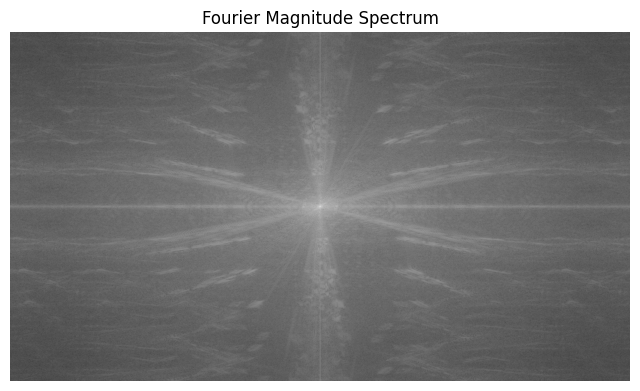

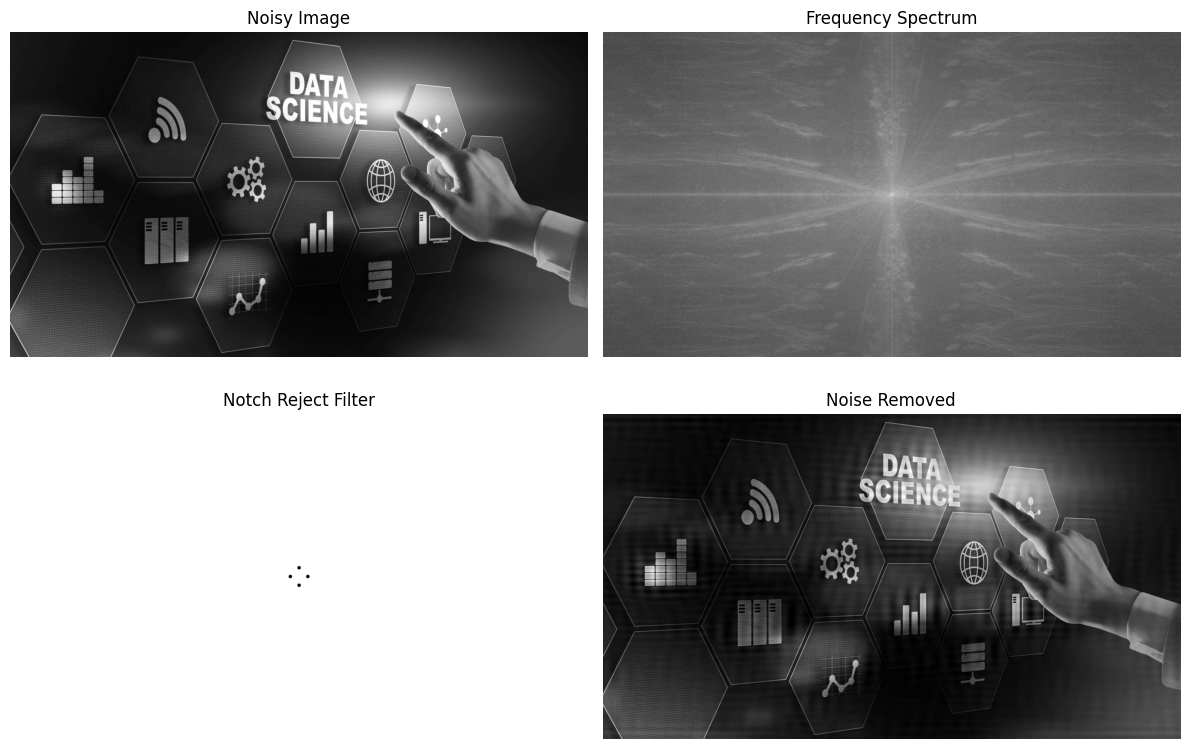

Vanshika Dhiman
CU24250228


In [ ]:
# 4.Build a periodic-noise removal tool hat identifies and removes noise spikes visible in the frequency spectrum.
import cv2
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. READ IMAGE
# --------------------------------------------------

image_path = "img2.jpg"

image = cv2.imread(
    image_path,
    cv2.IMREAD_GRAYSCALE
)

if image is None:
    print("Error: Image not found.")
    print("Check the image filename and location.")
    exit()

print("Image loaded successfully!")
print("Image size:", image.shape)


# --------------------------------------------------
# 2. FOURIER TRANSFORM
# --------------------------------------------------

# Compute 2D Fourier Transform
f = np.fft.fft2(image)

# Shift zero frequency to center
f_shift = np.fft.fftshift(f)


# --------------------------------------------------
# 3. MAGNITUDE SPECTRUM
# --------------------------------------------------

magnitude = np.abs(f_shift)

# Log transformation for visualization
magnitude_spectrum = np.log1p(magnitude)


# --------------------------------------------------
# 4. DISPLAY SPECTRUM
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.imshow(
    magnitude_spectrum,
    cmap="gray"
)

plt.title("Fourier Magnitude Spectrum")
plt.axis("off")

plt.show()


# --------------------------------------------------
# 5. CREATE NOTCH REJECT FILTER
# --------------------------------------------------

rows, cols = image.shape

crow = rows // 2
ccol = cols // 2

# Start with a filter that keeps everything
notch_filter = np.ones(
    (rows, cols),
    dtype=np.float32
)


# --------------------------------------------------
# 6. DEFINE NOISE SPIKES
# --------------------------------------------------

# IMPORTANT:
# Replace these coordinates after looking at
# your Fourier spectrum.

noise_spikes = [
    (ccol + 40, crow),
    (ccol - 40, crow),
    (ccol, crow + 40),
    (ccol, crow - 40)
]


# Radius of each notch
radius = 8


# --------------------------------------------------
# 7. REMOVE NOISE SPIKES
# --------------------------------------------------

Y, X = np.ogrid[:rows, :cols]

for x, y in noise_spikes:

    distance = np.sqrt(
        (X - x) ** 2 +
        (Y - y) ** 2
    )

    notch_filter[distance <= radius] = 0


# --------------------------------------------------
# 8. APPLY NOTCH FILTER
# --------------------------------------------------

filtered_frequency = (
    f_shift * notch_filter
)


# --------------------------------------------------
# 9. INVERSE FOURIER TRANSFORM
# --------------------------------------------------

# Shift frequency domain back
filtered_shift = np.fft.ifftshift(
    filtered_frequency
)

# Inverse Fourier Transform
result = np.fft.ifft2(
    filtered_shift
)

# Take magnitude
result = np.abs(result)


# Normalize result
result = cv2.normalize(
    result,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

result = result.astype(np.uint8)


# --------------------------------------------------
# 10. DISPLAY RESULTS
# --------------------------------------------------

plt.figure(figsize=(12, 8))


plt.subplot(2, 2, 1)

plt.imshow(
    image,
    cmap="gray"
)

plt.title("Noisy Image")
plt.axis("off")


plt.subplot(2, 2, 2)

plt.imshow(
    magnitude_spectrum,
    cmap="gray"
)

plt.title("Frequency Spectrum")
plt.axis("off")


plt.subplot(2, 2, 3)

plt.imshow(
    notch_filter,
    cmap="gray"
)

plt.title("Notch Reject Filter")
plt.axis("off")


plt.subplot(2, 2, 4)

plt.imshow(
    result,
    cmap="gray"
)

plt.title("Noise Removed")
plt.axis("off")


plt.tight_layout()

plt.show()
print("Vanshika Dhiman")
print("CU24250228")

Image loaded successfully!
Image size: (1485, 2640)
Total Fourier coefficients: 3920400

Compression Information
-----------------------
Total coefficients: 3920400
Coefficients kept: 5000
Percentage retained: 0.13 %
Compression ratio: 784.08 : 1


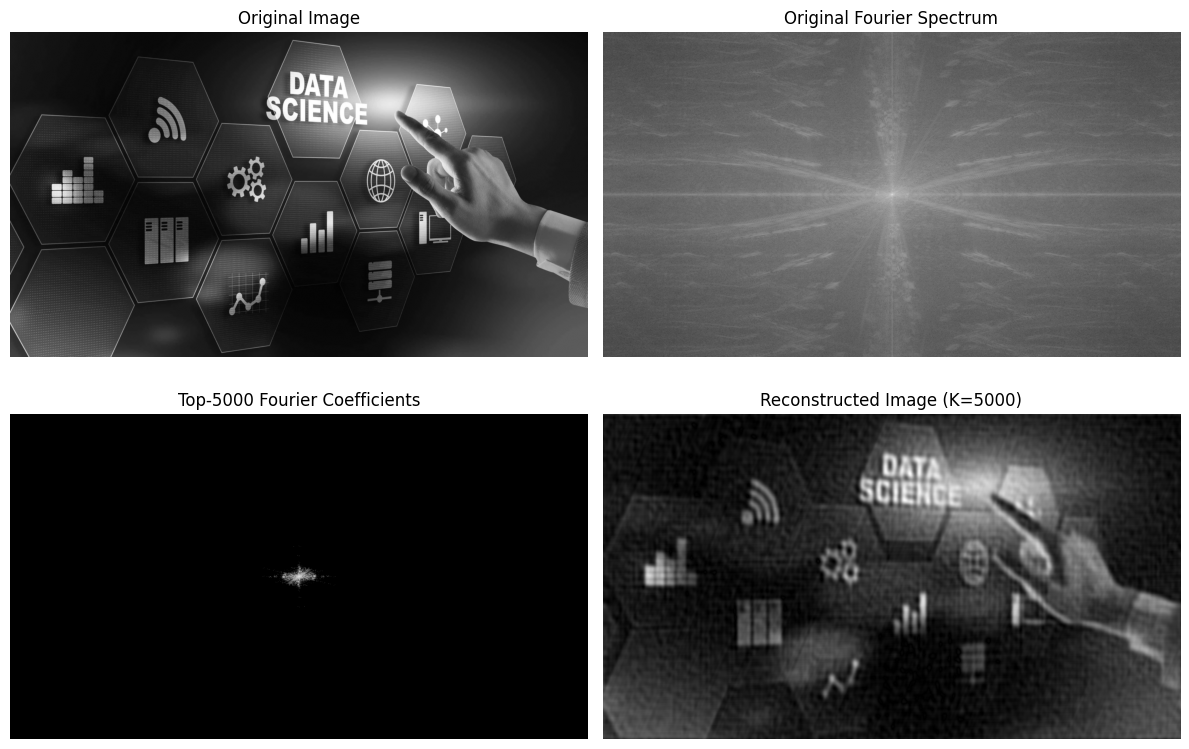

Vanshika Dhiman
CU24250228


In [ ]:
# 5.Develop a program that compresses an image by retaining only the top-k fourier coefficients and reconstructs it.
import cv2
import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------------
# 1. READ IMAGE
# --------------------------------------------------

image_path = "img2.jpg"

image = cv2.imread(
    image_path,
    cv2.IMREAD_GRAYSCALE
)

if image is None:
    print("Error: Image not found.")
    print("Check the image filename and location.")
    exit()

print("Image loaded successfully!")
print("Image size:", image.shape)


# --------------------------------------------------
# 2. FOURIER TRANSFORM
# --------------------------------------------------

# Compute 2D Fourier Transform
f = np.fft.fft2(image)

# Shift zero frequency to center
f_shift = np.fft.fftshift(f)


# --------------------------------------------------
# 3. CALCULATE MAGNITUDE
# --------------------------------------------------

magnitude = np.abs(f_shift)


# --------------------------------------------------
# 4. SELECT TOP-K COEFFICIENTS
# --------------------------------------------------

# Total number of Fourier coefficients
total_coefficients = magnitude.size

print("Total Fourier coefficients:",
      total_coefficients)

# Choose K
K = 5000

# Make sure K is valid
K = min(K, total_coefficients)

# Flatten magnitude
flat_magnitude = magnitude.flatten()

# Find indices of K largest coefficients
top_k_indices = np.argpartition(
    flat_magnitude,
    -K
)[-K:]


# --------------------------------------------------
# 5. CREATE COMPRESSED SPECTRUM
# --------------------------------------------------

compressed_f = np.zeros_like(f_shift)

# Flatten compressed array
compressed_flat = compressed_f.flatten()

# Keep only top-K coefficients
original_flat = f_shift.flatten()

compressed_flat[top_k_indices] = (
    original_flat[top_k_indices]
)

# Reshape back
compressed_f = compressed_flat.reshape(
    f_shift.shape
)


# --------------------------------------------------
# 6. RECONSTRUCT IMAGE
# --------------------------------------------------

# Shift back
compressed_shift = np.fft.ifftshift(
    compressed_f
)

# Inverse Fourier Transform
reconstructed = np.fft.ifft2(
    compressed_shift
)

# Take absolute value
reconstructed = np.abs(reconstructed)


# Normalize to 0-255
reconstructed = cv2.normalize(
    reconstructed,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

reconstructed = reconstructed.astype(
    np.uint8
)


# --------------------------------------------------
# 7. CALCULATE COMPRESSION RATIO
# --------------------------------------------------

compression_ratio = (
    total_coefficients / K
)

percentage_kept = (
    K / total_coefficients
) * 100

print("\nCompression Information")
print("-----------------------")
print("Total coefficients:", total_coefficients)
print("Coefficients kept:", K)
print(
    "Percentage retained:",
    round(percentage_kept, 2),
    "%"
)
print(
    "Compression ratio:",
    round(compression_ratio, 2),
    ": 1"
)


# --------------------------------------------------
# 8. DISPLAY RESULTS
# --------------------------------------------------

plt.figure(figsize=(12, 8))


# Original image
plt.subplot(2, 2, 1)

plt.imshow(
    image,
    cmap="gray"
)

plt.title("Original Image")

plt.axis("off")


# Original Fourier magnitude
plt.subplot(2, 2, 2)

plt.imshow(
    np.log1p(magnitude),
    cmap="gray"
)

plt.title("Original Fourier Spectrum")

plt.axis("off")


# Top-K spectrum
plt.subplot(2, 2, 3)

compressed_magnitude = np.abs(
    compressed_f
)

plt.imshow(
    np.log1p(compressed_magnitude),
    cmap="gray"
)

plt.title(
    f"Top-{K} Fourier Coefficients"
)

plt.axis("off")


# Reconstructed image
plt.subplot(2, 2, 4)

plt.imshow(
    reconstructed,
    cmap="gray"
)

plt.title(
    f"Reconstructed Image (K={K})"
)

plt.axis("off")


plt.tight_layout()

plt.show()
print("Vanshika Dhiman")
print("CU24250228")

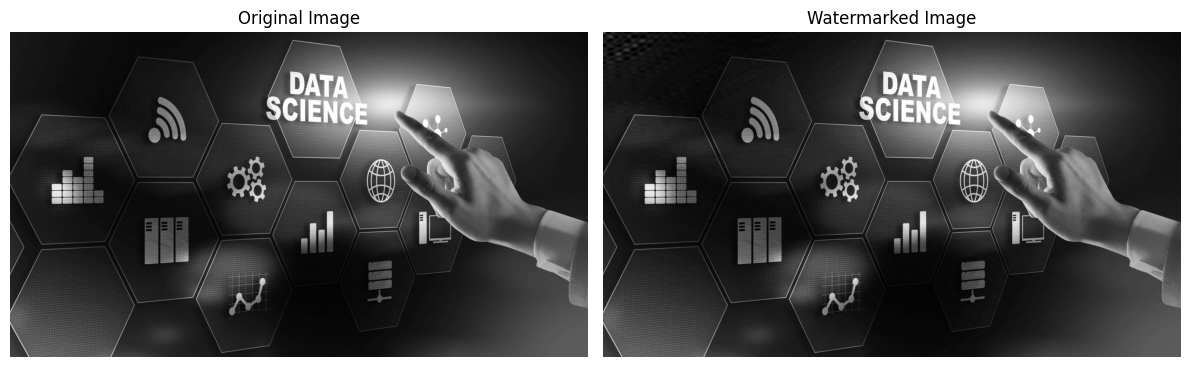

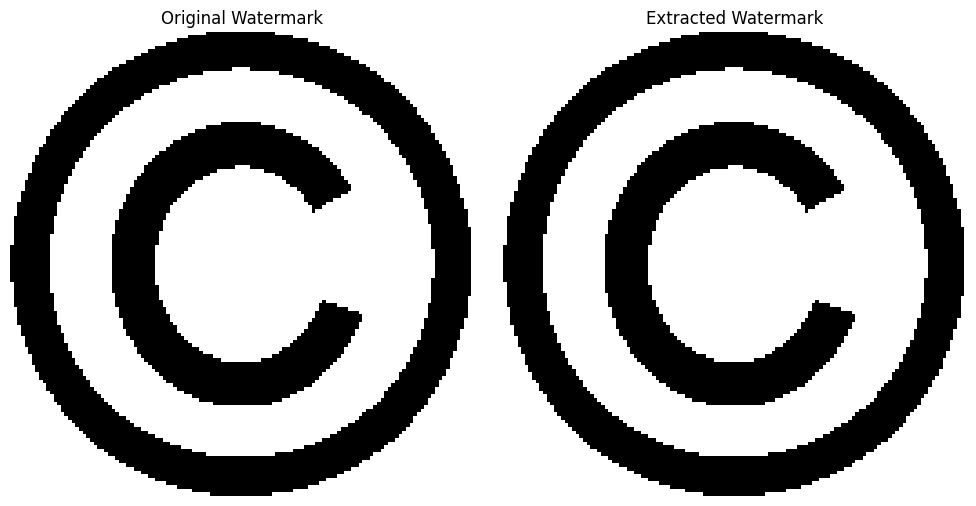

Watermark embedding completed.
Watermark extraction completed.
Watermarked image saved as: watermarked_image.png


In [ ]:
# 6.create a watermark hide/reveal tool that enbeds and extracts a watermark using frequency  domain manipulation
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load original image
image = cv2.imread("img2.jpg", cv2.IMREAD_GRAYSCALE)

# Load watermark image
watermark = cv2.imread("watermark.png", cv2.IMREAD_GRAYSCALE)

if image is None or watermark is None:
    print("Error: Please check image.jpg and watermark.png")
else:
    # Resize watermark
    watermark = cv2.resize(watermark, (128, 128))

    # Convert watermark to binary
    _, watermark_binary = cv2.threshold(
        watermark, 127, 1, cv2.THRESH_BINARY
    )

    # Convert original image to float
    image_float = np.float32(image)

    # Apply DCT to convert image to frequency domain
    dct_image = cv2.dct(image_float)

    # Keep original DCT for extraction
    original_dct = dct_image.copy()

    # Watermark embedding parameters
    alpha = 20
    start_row = 10
    start_col = 10

    # Embed watermark in frequency domain
    for i in range(128):
        for j in range(128):
            if watermark_binary[i, j] == 1:
                dct_image[start_row+i, start_col+j] += alpha
            else:
                dct_image[start_row+i, start_col+j] -= alpha

    # Convert back to spatial domain using IDCT
    watermarked_image = cv2.idct(dct_image)

    # Convert to 8-bit image
    watermarked_image = np.clip(
        watermarked_image, 0, 255
    ).astype(np.uint8)

    # Save watermarked image
    cv2.imwrite("watermarked_image.png", watermarked_image)

    # Display original and watermarked image
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(watermarked_image, cmap="gray")
    plt.title("Watermarked Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # REVEAL / EXTRACT WATERMARK
    # ---------------------------------------------------------

    # Apply DCT to watermarked image
    watermarked_dct = cv2.dct(
        np.float32(watermarked_image)
    )

    # Create empty extracted watermark
    extracted_watermark = np.zeros(
        (128, 128), dtype=np.uint8
    )

    # Extract watermark by comparing frequency coefficients
    for i in range(128):
        for j in range(128):

            original_value = original_dct[
                start_row+i, start_col+j
            ]

            watermarked_value = watermarked_dct[
                start_row+i, start_col+j
            ]

            if watermarked_value > original_value:
                extracted_watermark[i, j] = 255
            else:
                extracted_watermark[i, j] = 0

    # Display original and extracted watermark
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(watermark_binary, cmap="gray")
    plt.title("Original Watermark")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(extracted_watermark, cmap="gray")
    plt.title("Extracted Watermark")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Watermark embedding completed.")
    print("Watermark extraction completed.")
    print("Watermarked image saved as: watermarked_image.png")

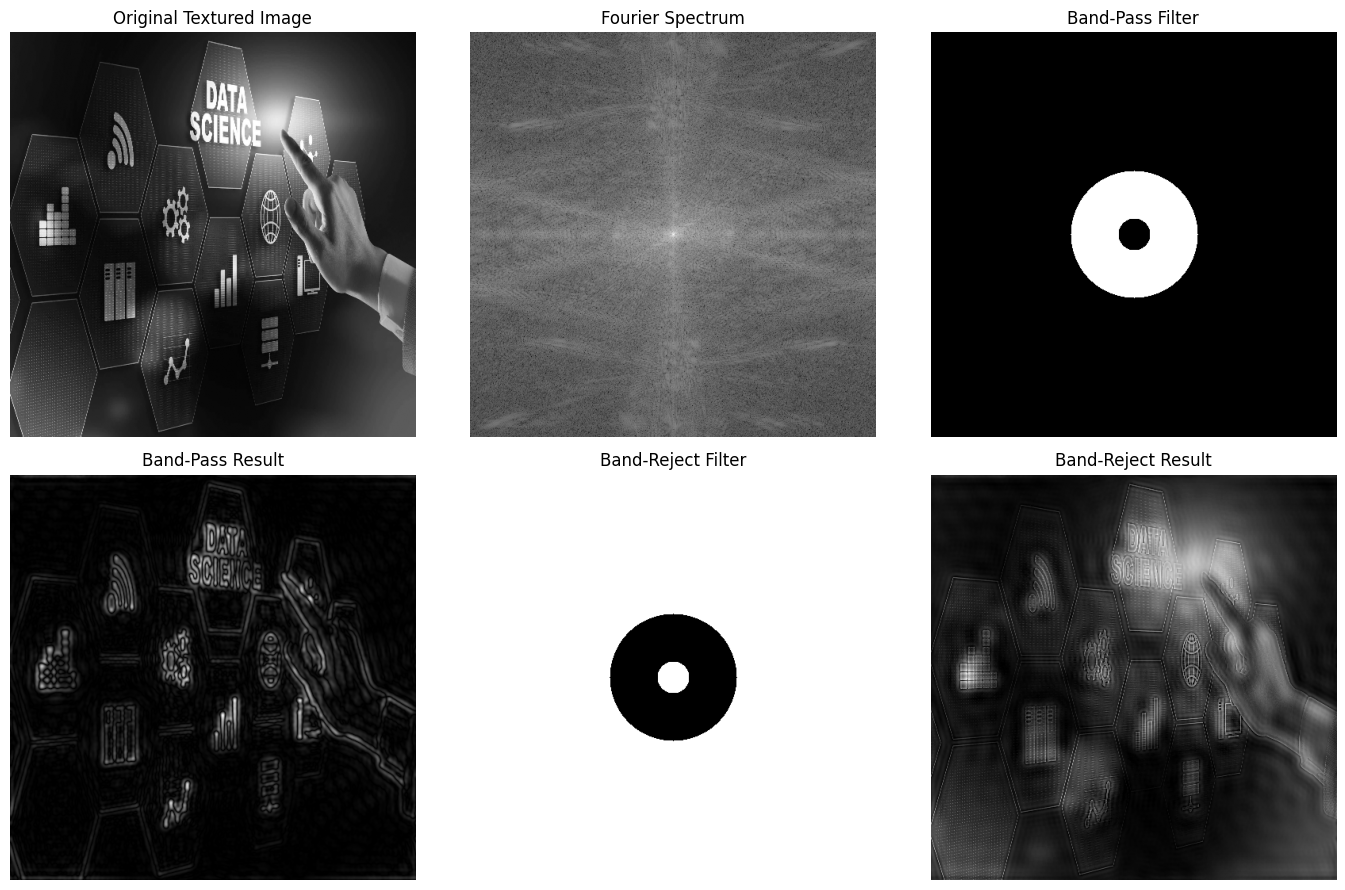

Band-Pass and Band-Reject filtering completed.
Low cutoff frequency : 20
High cutoff frequency: 80


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load textured image
image_path="img2.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError("Image not found. Check the image path.")

# Resize image
image = cv2.resize(image, (512, 512))

# Fourier Transform
f = np.fft.fft2(image)
fshift = np.fft.fftshift(f)

# Calculate Fourier magnitude spectrum
magnitude_spectrum = np.log(1 + np.abs(fshift))

# Get image dimensions and center
rows, cols = image.shape
crow, ccol = rows // 2, cols // 2

# Frequency range
low_cutoff = 20
high_cutoff = 80

# Create distance matrix
y, x = np.ogrid[:rows, :cols]
distance = np.sqrt((x - ccol)**2 + (y - crow)**2)

# ---------------- BAND-PASS FILTER ----------------
# Keeps frequencies between low and high cutoff
band_pass = np.logical_and(
    distance >= low_cutoff,
    distance <= high_cutoff
).astype(np.float32)

# Apply band-pass filter
bp_filtered = fshift * band_pass

# Inverse Fourier Transform
bp_inverse = np.fft.ifftshift(bp_filtered)
band_pass_result = np.fft.ifft2(bp_inverse)

# Convert to displayable image
band_pass_result = np.abs(band_pass_result)
band_pass_result = cv2.normalize(
    band_pass_result, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

# ---------------- BAND-REJECT FILTER ----------------
# Removes frequencies between low and high cutoff
band_reject = np.logical_or(
    distance < low_cutoff,
    distance > high_cutoff
).astype(np.float32)

# Apply band-reject filter
br_filtered = fshift * band_reject

# Inverse Fourier Transform
br_inverse = np.fft.ifftshift(br_filtered)
band_reject_result = np.fft.ifft2(br_inverse)

# Convert to displayable image
band_reject_result = np.abs(band_reject_result)
band_reject_result = cv2.normalize(
    band_reject_result, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

# ---------------- DISPLAY RESULTS ----------------

plt.figure(figsize=(14, 9))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Textured Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Fourier Spectrum")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(band_pass, cmap="gray")
plt.title("Band-Pass Filter")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(band_pass_result, cmap="gray")
plt.title("Band-Pass Result")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(band_reject, cmap="gray")
plt.title("Band-Reject Filter")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(band_reject_result, cmap="gray")
plt.title("Band-Reject Result")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Band-Pass and Band-Reject filtering completed.")
print("Low cutoff frequency :", low_cutoff)
print("High cutoff frequency:", high_cutoff)

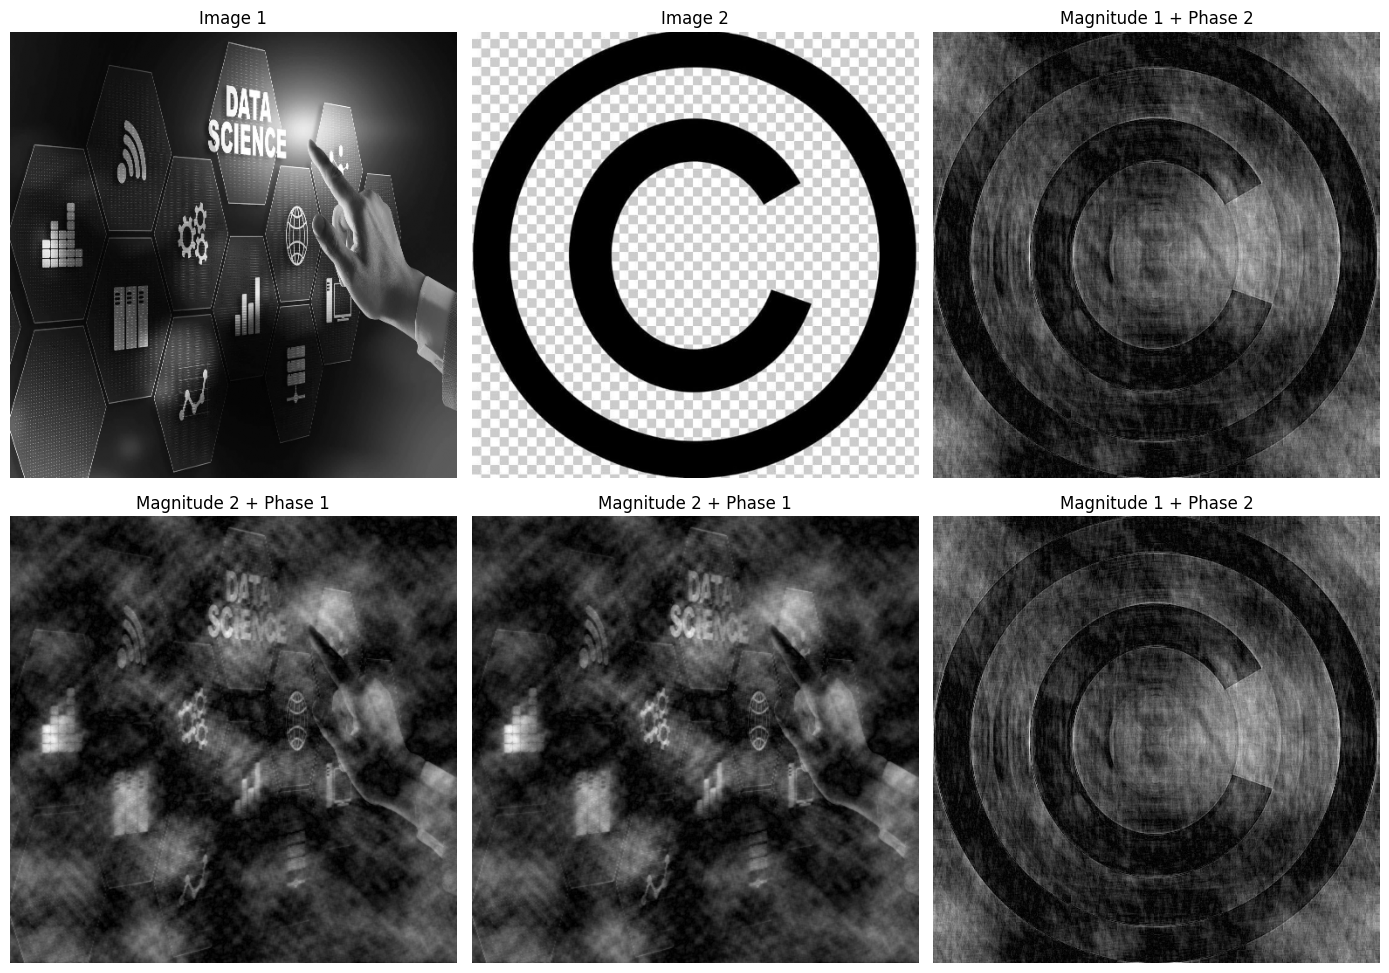

Phase and magnitude swapping completed successfully.


In [ ]:
# 8.Develop a demo that swaps the phase and magnitude components btw two images to show their relative importance.
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load two images in grayscale
image1 = cv2.imread("img2.jpg", cv2.IMREAD_GRAYSCALE)
image2 = cv2.imread("watermark.png", cv2.IMREAD_GRAYSCALE)

# Check images
if image1 is None or image2 is None:
    raise FileNotFoundError("Make sure image1.jpg and image2.jpg exist.")

# Resize both images to the same size
image1 = cv2.resize(image1, (512, 512))
image2 = cv2.resize(image2, (512, 512))

# Fourier Transform
fft1 = np.fft.fft2(image1)
fft2 = np.fft.fft2(image2)

# Shift zero frequency to center
fft1_shift = np.fft.fftshift(fft1)
fft2_shift = np.fft.fftshift(fft2)

# Extract magnitude and phase
magnitude1 = np.abs(fft1_shift)
phase1 = np.angle(fft1_shift)

magnitude2 = np.abs(fft2_shift)
phase2 = np.angle(fft2_shift)

# ---------------------------------------------------------
# Swap Phase Components
# Magnitude of Image 1 + Phase of Image 2
# ---------------------------------------------------------

phase_swap_1 = magnitude1 * np.exp(1j * phase2)

result_phase_swap_1 = np.fft.ifft2(
    np.fft.ifftshift(phase_swap_1)
)

result_phase_swap_1 = np.abs(result_phase_swap_1)

# ---------------------------------------------------------
# Swap Phase Components
# Magnitude of Image 2 + Phase of Image 1
# ---------------------------------------------------------

phase_swap_2 = magnitude2 * np.exp(1j * phase1)

result_phase_swap_2 = np.fft.ifft2(
    np.fft.ifftshift(phase_swap_2)
)

result_phase_swap_2 = np.abs(result_phase_swap_2)

# ---------------------------------------------------------
# Swap Magnitude Components
# Magnitude of Image 1 + Phase of Image 2
# and Magnitude of Image 2 + Phase of Image 1
# ---------------------------------------------------------

magnitude_swap_1 = magnitude2 * np.exp(1j * phase1)

result_magnitude_swap_1 = np.fft.ifft2(
    np.fft.ifftshift(magnitude_swap_1)
)

result_magnitude_swap_1 = np.abs(result_magnitude_swap_1)

magnitude_swap_2 = magnitude1 * np.exp(1j * phase2)

result_magnitude_swap_2 = np.fft.ifft2(
    np.fft.ifftshift(magnitude_swap_2)
)

result_magnitude_swap_2 = np.abs(result_magnitude_swap_2)

# Normalize results for display
result_phase_swap_1 = cv2.normalize(
    result_phase_swap_1, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

result_phase_swap_2 = cv2.normalize(
    result_phase_swap_2, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

result_magnitude_swap_1 = cv2.normalize(
    result_magnitude_swap_1, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

result_magnitude_swap_2 = cv2.normalize(
    result_magnitude_swap_2, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)

# ---------------------------------------------------------
# Display Results
# ---------------------------------------------------------

plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1)
plt.imshow(image1, cmap="gray")
plt.title("Image 1")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(image2, cmap="gray")
plt.title("Image 2")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(result_phase_swap_1, cmap="gray")
plt.title("Magnitude 1 + Phase 2")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(result_phase_swap_2, cmap="gray")
plt.title("Magnitude 2 + Phase 1")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(result_magnitude_swap_1, cmap="gray")
plt.title("Magnitude 2 + Phase 1")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(result_magnitude_swap_2, cmap="gray")
plt.title("Magnitude 1 + Phase 2")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Phase and magnitude swapping completed successfully.")

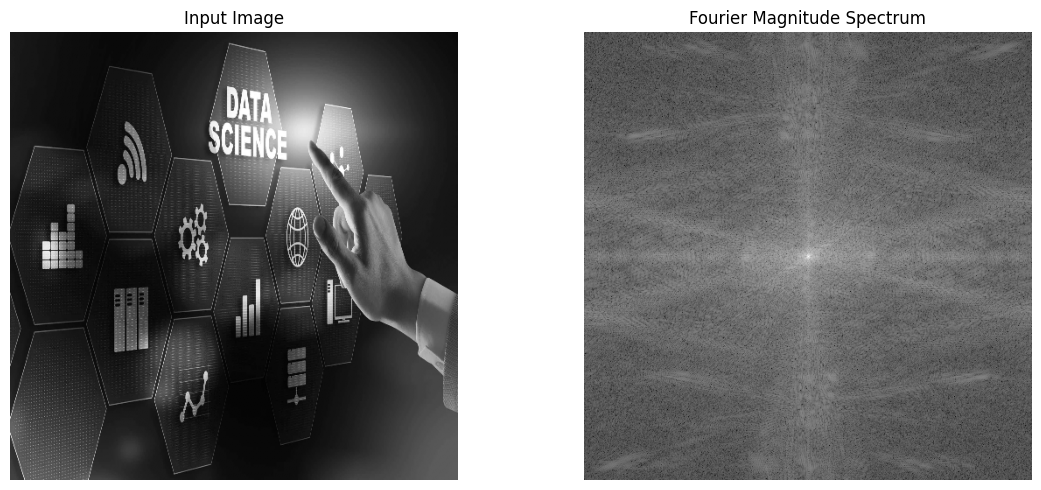

----------------------------------------
       BLUR DETECTION RESULT
----------------------------------------
High-frequency energy: 19103416615530.203
Total frequency energy: 369727050350592.0
High-frequency energy percentage: 5.17 %
Threshold: 10.0 %
----------------------------------------
Result: BLURRY IMAGE
----------------------------------------


In [ ]:
# 9 Create a blur-detection tool that flags blurry images based on the high-frequency energy content of their spectrum.
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Blur Detection using High-Frequency Energy
# ---------------------------------------------------------

# Load image
image_path = "img2.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError("Image not found. Check the image path.")

# Resize image
image = cv2.resize(image, (512, 512))

# ---------------------------------------------------------
# Fourier Transform
# ---------------------------------------------------------

fft = np.fft.fft2(image)
fft_shift = np.fft.fftshift(fft)

# Calculate magnitude spectrum
magnitude = np.abs(fft_shift)

# Calculate energy spectrum
energy_spectrum = magnitude ** 2

# ---------------------------------------------------------
# Create high-frequency mask
# ---------------------------------------------------------

rows, cols = image.shape
crow, ccol = rows // 2, cols // 2

y, x = np.ogrid[:rows, :cols]
distance = np.sqrt((x - ccol) ** 2 + (y - crow) ** 2)

# Radius below which frequencies are considered low-frequency
low_frequency_radius = 50

# High-frequency region
high_frequency_mask = distance > low_frequency_radius

# Calculate high-frequency energy
high_frequency_energy = np.sum(
    energy_spectrum[high_frequency_mask]
)

# Calculate total energy
total_energy = np.sum(energy_spectrum)

# Calculate percentage of energy in high frequencies
high_frequency_percentage = (
    high_frequency_energy / total_energy
) * 100

# ---------------------------------------------------------
# Blur Decision
# ---------------------------------------------------------

# Threshold for blur detection
threshold = 10.0

if high_frequency_percentage < threshold:
    result = "BLURRY IMAGE"
else:
    result = "SHARP IMAGE"

# ---------------------------------------------------------
# Display Results
# ---------------------------------------------------------

magnitude_spectrum = np.log(1 + magnitude)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(magnitude_spectrum, cmap="gray")
plt.title("Fourier Magnitude Spectrum")
plt.axis("off")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Print Results
# ---------------------------------------------------------

print("----------------------------------------")
print("       BLUR DETECTION RESULT")
print("----------------------------------------")
print("High-frequency energy:", high_frequency_energy)
print("Total frequency energy:", total_energy)
print("High-frequency energy percentage:",
      round(high_frequency_percentage, 2), "%")
print("Threshold:", threshold, "%")
print("----------------------------------------")
print("Result:", result)
print("----------------------------------------")

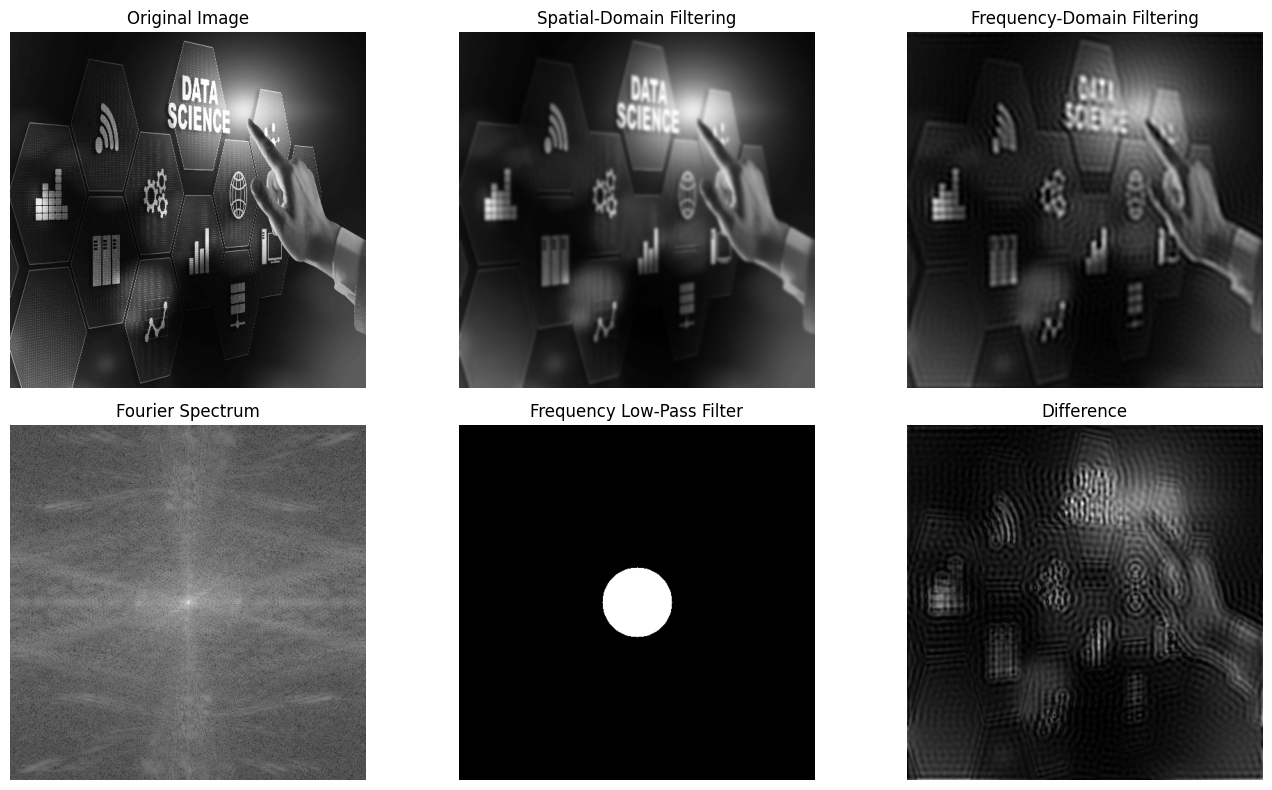

Spatial-domain and frequency-domain filtering comparison completed.


In [ ]:
# 10  Build a side-by-side visuaizer comparing  spatial-domain and frequency-domain filtering results for the same image.
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image_path = "img2.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    raise FileNotFoundError("Image not found. Check the image path.")

# Resize image
image = cv2.resize(image, (512, 512))

# ---------------------------------------------------------
# SPATIAL-DOMAIN FILTERING
# ---------------------------------------------------------

# Gaussian Blur in spatial domain
spatial_result = cv2.GaussianBlur(
    image,
    (11, 11),
    0
)

# ---------------------------------------------------------
# FREQUENCY-DOMAIN FILTERING
# ---------------------------------------------------------

# Fourier Transform
fft = np.fft.fft2(image)
fft_shift = np.fft.fftshift(fft)

# Image dimensions and center
rows, cols = image.shape
crow, ccol = rows // 2, cols // 2

# Create distance matrix
y, x = np.ogrid[:rows, :cols]
distance = np.sqrt(
    (x - ccol) ** 2 +
    (y - crow) ** 2
)

# Create a low-pass filter
cutoff = 50

frequency_filter = (
    distance <= cutoff
).astype(np.float32)

# Apply filter
filtered_fft = fft_shift * frequency_filter

# Inverse Fourier Transform
inverse_fft = np.fft.ifftshift(filtered_fft)
frequency_result = np.fft.ifft2(inverse_fft)

# Convert result to displayable image
frequency_result = np.abs(frequency_result)

frequency_result = cv2.normalize(
    frequency_result,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

# ---------------------------------------------------------
# FREQUENCY SPECTRUM
# ---------------------------------------------------------

spectrum = np.log(
    1 + np.abs(fft_shift)
)

# ---------------------------------------------------------
# SIDE-BY-SIDE VISUALIZATION
# ---------------------------------------------------------

plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(spatial_result, cmap="gray")
plt.title("Spatial-Domain Filtering")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(frequency_result, cmap="gray")
plt.title("Frequency-Domain Filtering")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(spectrum, cmap="gray")
plt.title("Fourier Spectrum")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(frequency_filter, cmap="gray")
plt.title("Frequency Low-Pass Filter")
plt.axis("off")

# Difference between two filtering results
difference = cv2.absdiff(
    spatial_result,
    frequency_result
)

plt.subplot(2, 3, 6)
plt.imshow(difference, cmap="gray")
plt.title("Difference")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Spatial-domain and frequency-domain filtering comparison completed.")